# Apartment Sale Price Analysis — Mexico City Metro Area

Data cleaning and exploratory analysis of **Mercado Libre Inmuebles** listings for five municipalities in the Valle de México metro area: Atizapán de Zaragoza, Azcapotzalco, Gustavo A. Madero, Naucalpan, and Tlalnepantla.

**Data source:** `departamentos_TODOS.csv`, generated by the project's manual scraping pipeline (see `parsear_multiples_municipios.py`).


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

plt.rcParams['figure.facecolor'] = 'white'


## 1. Load data

In [20]:
df = pd.read_csv('resultados/departamentos_TODOS.csv', encoding='utf-8-sig')

# Rename columns to English for readability
df = df.rename(columns={
    'titulo': 'title', 'precio': 'price', 'moneda': 'currency', 'ubicacion': 'location',
    'superficie': 'surface_raw', 'recamaras': 'bedrooms_raw', 'banos': 'bathrooms_raw',
    'link': 'link', 'imagen': 'image', 'municipio': 'municipality'
})

print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
df.head(3)


Rows: 2431  |  Columns: 10


,title,price,currency,location,surface_raw,bedrooms_raw,bathrooms_raw,link,image,municipality
0,"Departamento En Venta, Atizapán De Zaragoza, 2...",3150000,MXN,"San Miguel Xochimanga, Atizapán De Zaragoza, E...",100 m² construidos,2 recámaras,2 baños,https://departamento.mercadolibre.com.mx/MLM-4...,https://http2.mlstatic.com/D_NQ_NP_2X_610221-M...,ATIZAPAN DE ZARAGOZA
1,"Departamento En Venta, Atizapán De Zaragoza, 3...",2850000,MXN,"San Miguel Xochimanga, Atizapán De Zaragoza, E...",81 m² construidos,3 recámaras,2 baños,https://departamento.mercadolibre.com.mx/MLM-5...,https://http2.mlstatic.com/D_NQ_NP_2X_914896-M...,ATIZAPAN DE ZARAGOZA
2,"Departamento En Venta, Ph Lomas De Valle Escon...",33728800,MXN,"Lomas De Valle Escondido, Atizapán De Zaragoza...",829 m² construidos,5 recámaras,6 baños,https://departamento.mercadolibre.com.mx/MLM-4...,https://http2.mlstatic.com/D_NQ_NP_2X_797160-M...,ATIZAPAN DE ZARAGOZA


Several columns (`price`, `surface_raw`, `bedrooms_raw`, `bathrooms_raw`) arrive as free text because that's how the parser extracted them straight from the HTML — we need to convert them to numeric values before any analysis.

### Missing values before cleaning

In [21]:
df.isna().sum()


title             0
price             0
currency          0
location          0
surface_raw       2
bedrooms_raw     21
bathrooms_raw     6
link              0
image             0
municipality      0
dtype: int64

## 2. Data cleaning

In [22]:
def extract_number(value):
    """Extract the first number from a string like '2 recámaras' or '85 m²'."""
    if pd.isna(value):
        return np.nan
    match = re.search(r'\d+', str(value).replace(',', ''))
    return float(match.group()) if match else np.nan

df['surface_m2'] = df['surface_raw'].apply(extract_number)
df['bedrooms']   = df['bedrooms_raw'].apply(extract_number)
df['bathrooms']  = df['bathrooms_raw'].apply(extract_number)
df['municipality'] = df['municipality'].str.title()

df[['surface_m2', 'bedrooms', 'bathrooms']].describe()


,surface_m2,bedrooms,bathrooms
count,2429.000000,2410.000000,2425.000000
mean,162.626595,2.558921,2.223505
std,116.473181,0.687350,1.282797
min,2.000000,1.000000,1.000000
25%,71.000000,2.000000,2.000000
50%,117.000000,3.000000,2.000000
75%,235.000000,3.000000,3.000000
max,1087.000000,15.000000,35.000000


### Duplicates and incomplete records

Some listings may repeat across saved pages that overlap. We use `link` as the unique identifier. We also drop rows missing price or surface area — without both, price per square meter (the central metric here) can't be computed.

In [23]:
n0 = len(df)
df = df.drop_duplicates(subset='link')
n1 = len(df)
df = df.dropna(subset=['price', 'surface_m2'])
n2 = len(df)

print(f'Original rows:                        {n0}')
print(f'After removing duplicates (link):     {n1}  (-{n0-n1})')
print(f'After dropping missing price/surface: {n2}  (-{n1-n2})')


Original rows:                        2431
After removing duplicates (link):     2431  (-0)
After dropping missing price/surface: 2429  (-2)


### Outliers

Some listings have prices or surface areas that don't correspond to real apartments (data entry errors, misclassified land listings, or placeholder prices). We apply two filters:

- **Price:** trim the bottom and top 1% (1st–99th percentile).
- **Surface area:** cap to a reasonable range for a residential apartment (15–400 m²), excluding both mis-captured studios and misclassified warehouses/land listed as 'apartment'.

In [24]:
p_low, p_high = df['price'].quantile([0.01, 0.99])
s_low, s_high = 15, 400

print(f'Price — 1st percentile: \${p_low:,.0f}   99th percentile: \${p_high:,.0f}')
print(f'Surface — applied bounds: {s_low} to {s_high} m2')


Price — 1st percentile: \$1,192,450   99th percentile: \$23,000,000
Surface — applied bounds: 15 to 400 m2


<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\enrik\AppData\Local\Temp\ipykernel_32536\1009391384.py:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  print(f'Price — 1st percentile: \${p_low:,.0f}   99th percentile: \${p_high:,.0f}')
C:\Users\enrik\AppData\Local\Temp\ipykernel_32536\1009391384.py:4: SyntaxWarning: "\$" i

In [25]:
n_before = len(df)
df = df[(df['price'].between(p_low, p_high)) & (df['surface_m2'].between(s_low, s_high))]
n_after = len(df)
df['price_per_m2'] = df['price'] / df['surface_m2']

print(f'Rows before outlier filtering: {n_before}')
print(f'Rows after:                    {n_after}  (-{n_before-n_after} dropped, {(n_before-n_after)/n_before:.1%})')


Rows before outlier filtering: 2429
Rows after:                    2314  (-115 dropped, 4.7%)


In [26]:
# Remove USD listings to keep all prices comparable in MXN.
currency_codes = df["currency"].astype("string").str.strip().str.upper()
df = df.loc[~currency_codes.isin(["USD", "US$"])].copy()

In [27]:
bathroom_counts = pd.to_numeric(
    df["bathrooms_raw"]
    .astype("string")
    .str.replace(r"\s*baños?\s*", "", regex=True),
    errors="coerce",
)

# Remove listings with suspicious bathroom counts.
df = df.loc[~bathroom_counts.isin([35, 11])].copy()

In [28]:
df[['surface_m2', 'bedrooms', 'bathrooms']].describe()

,surface_m2,bedrooms,bathrooms
count,2311.000000,2292.000000,2306.000000
mean,150.922112,2.528796,2.156982
std,95.083741,0.608072,0.815036
min,32.000000,1.000000,1.000000
25%,70.000000,2.000000,2.000000
50%,113.000000,3.000000,2.000000
75%,221.000000,3.000000,3.000000
max,400.000000,8.000000,7.000000


## 3. Exploratory analysis

### Summary by municipality

In [29]:
summary = df.groupby('municipality').agg(
    listings=('price', 'count'),
    median_price=('price', 'median'),
    median_surface=('surface_m2', 'median'),
    median_price_per_m2=('price_per_m2', 'median'),
).sort_values('median_price', ascending=False)

summary


,listings,median_price,median_surface,median_price_per_m2
municipality,,,,
Naucalpan,1032,8894000.0,219.5,43000.000000
Tlalnepantla,261,4300000.0,98.0,43877.551020
Atizapan De Zaragoza,413,3661500.0,108.0,37000.000000
Azcapotzalco,322,3124081.5,63.5,46802.230769
Gustavo A Madero,283,2755817.0,64.0,42162.162162


### Price distribution by municipality

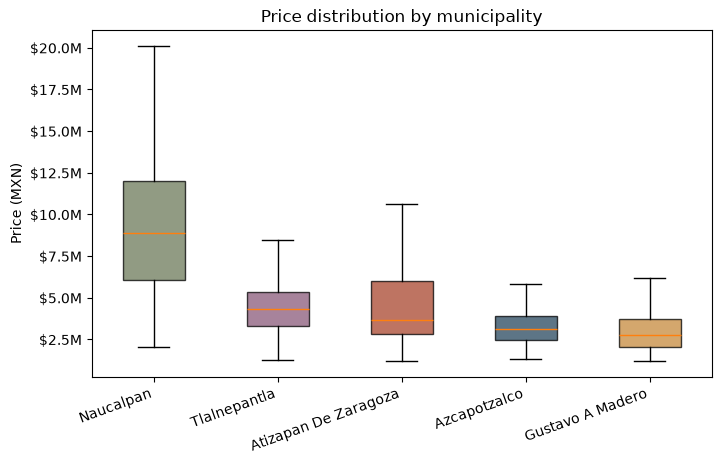

In [30]:
MUNI_COLORS = {
    'Atizapan De Zaragoza': '#A8452E', 'Azcapotzalco': '#27475E',
    'Gustavo A Madero': '#C68A3C', 'Naucalpan': '#6C7A5A', 'Tlalnepantla': '#8A5A7A'
}
order = summary.index.tolist()
fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot([df[df.municipality == m]['price'] for m in order], tick_labels=order,
                patch_artist=True, showfliers=False)
for patch, m in zip(bp['boxes'], order):
    patch.set_facecolor(MUNI_COLORS.get(m, '#999')); patch.set_alpha(0.75)
ax.set_ylabel('Price (MXN)')
ax.yaxis.set_major_formatter(lambda x, pos: f'${x/1e6:.1f}M')
plt.xticks(rotation=20, ha='right')
ax.set_title('Price distribution by municipality')
plt.show()


### Price per square meter

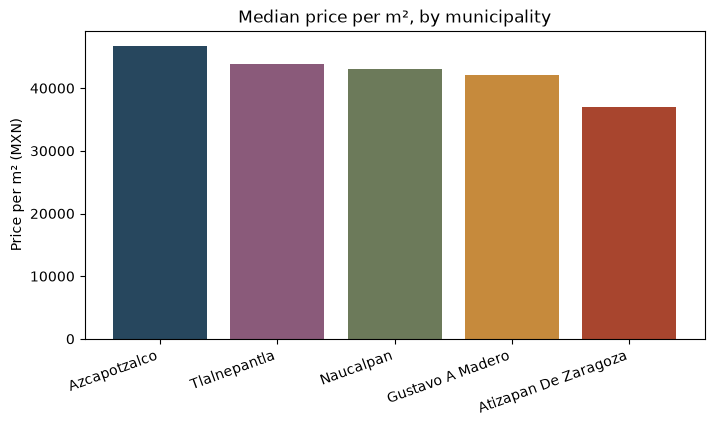

In [31]:
vals = summary.sort_values('median_price_per_m2', ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vals.index, vals['median_price_per_m2'], color=[MUNI_COLORS.get(m, '#999') for m in vals.index])
ax.set_ylabel('Price per m² (MXN)')
ax.set_title('Median price per m², by municipality')
plt.xticks(rotation=20, ha='right')
plt.show()


### Price vs. surface area

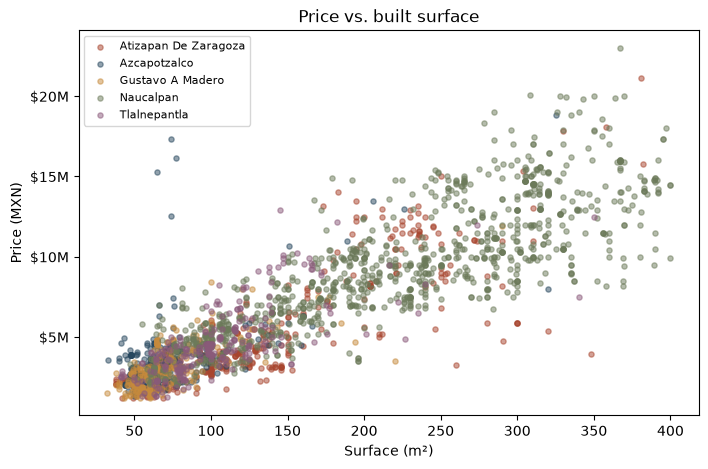

Surface-price correlation: 0.889


In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
for m, color in MUNI_COLORS.items():
    sub = df[df.municipality == m]
    ax.scatter(sub['surface_m2'], sub['price'], s=14, alpha=0.5, color=color, label=m)
ax.set_xlabel('Surface (m²)'); ax.set_ylabel('Price (MXN)')
ax.yaxis.set_major_formatter(lambda x, pos: f'${x/1e6:.0f}M')
ax.legend(fontsize=8, loc='upper left')
ax.set_title('Price vs. built surface')
plt.show()

print('Surface-price correlation:', round(df[["surface_m2", "price"]].corr().iloc[0, 1], 3))


### Bedroom distribution

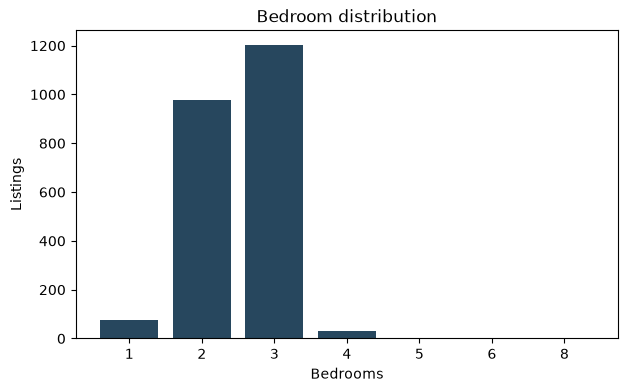

In [33]:
counts = df['bedrooms'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index.astype(int).astype(str), counts.values, color='#27475E')
ax.set_xlabel('Bedrooms'); ax.set_ylabel('Listings')
ax.set_title('Bedroom distribution')
plt.show()


## 4. Key findings

- **Atizapán de Zaragoza has the lowest price per m²** of the five municipalities (~\$37,000/m²), despite not having the lowest overall median price — its units tend to be larger than average.
- **Azcapotzalco is the most expensive per m²** (~\$46,800/m²) despite relatively small units (median 63 m²) — it has the weakest space-to-price ratio of the five.
- **Naucalpan accounts for the largest share of listings** (1,034 of 2,314 after cleaning, ~45% of the total) and also has the largest median surface area (220 m²) — worth checking whether this reflects genuinely larger developments in the area or possible misclassification (e.g., houses listed as apartments) to audit in a future iteration.
- **Price and surface area are strongly correlated** (r = 0.89), as expected — size explains most of the variation in price, though the price-per-m² relationship still varies meaningfully across municipalities (see chart above).

*(After cleaning and outlier filtering, the final dataset has 2,314 listings.)*

## 5. Export cleaned dataset

In [34]:
df.to_csv('Apartment_Price_Analysis_Clean.csv', index=False, encoding='utf-8-sig')
print(f'Saved: Apartment_Price_Analysis_Clean.csv  ({len(df)} rows, {df.shape[1]} columns)')


Saved: Apartment_Price_Analysis_Clean.csv  (2311 rows, 14 columns)
